In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math, copy

In [2]:
Hours = np.random.randint(1, 11, 100)
Sleep = np.random.randint(5, 10, 100)
Attendance = np.random.randint(60, 101, 100)
Previous = np.random.randint(40, 91, 100)

Score = (
    2.5 * Hours +
    1.5 * Sleep +
    0.3 * Attendance +
    0.5 * Previous +
    np.random.normal(0, 3, 100)
)

In [38]:
X_train = np.column_stack((Hours, Sleep, Attendance, Previous))
y_train = Score

In [39]:
print(X_train)
print(y_train)

[[  8   8  72  48]
 [  9   9  99  50]
 [  2   8  98  62]
 [  7   9  71  52]
 [ 10   9  72  70]
 [  9   8  88  67]
 [  4   8  80  53]
 [  6   5  95  41]
 [  3   6  81  41]
 [  1   6  90  84]
 [  7   7  94  83]
 [  5   8  75  61]
 [  6   7  63  88]
 [  7   8  61  61]
 [  4   9  84  81]
 [  1   9  80  62]
 [  7   9  74  69]
 [  6   6  82  51]
 [  6   7  91  77]
 [  8   6  64  66]
 [  5   5  60  67]
 [  7   6  97  68]
 [  6   6  67  63]
 [  3   9  96  44]
 [  3   5  79  74]
 [  3   6  82  60]
 [  8   7  66  76]
 [  3   9  66  73]
 [  4   6  71  85]
 [ 10   9  90  69]
 [  4   6  60  78]
 [  7   8  69  43]
 [  8   6  67  71]
 [ 10   5  89  51]
 [  8   7  85  88]
 [  2   7  83  90]
 [  4   5  94  90]
 [  2   7  97  52]
 [  8   9  84  69]
 [  2   6  76  43]
 [  2   8  93  47]
 [  4   8  75  79]
 [  1   7  63  81]
 [  4   7  86  73]
 [  7   7  92  74]
 [  5   9  76  77]
 [  9   9  80  46]
 [  8   6  72  79]
 [  1   7  79  43]
 [  8   7  61  85]
 [  7   7  97  58]
 [ 10   5  91  65]
 [  4   7  8

In [27]:
def zscore_normalization(X):

    mu = np.mean(X, axis=0)

    sigma = np.std(X, axis=0)

    X_norm = (X - mu) / sigma

    return (X_norm, mu, sigma)

In [56]:
def compute_cost(X,y,w,b):

    m = len(X)
    cost = 0

    total_cost = 0

    for i in range(m):
        f_wb = np.dot(X[i], w) + b
        cost += (f_wb - y[i]) ** 2

    total_cost = cost / (2*m)
    return total_cost

In [57]:
def compute_gradient(X,y,w,b):

    m = len(X)
    dj_dw = 0
    dj_db = 0

    for i in range(m):
        f_wb = np.dot(X[i], w) + b
        dj_dw += (f_wb - y[i]) * X[i]
        dj_db += (f_wb - y[i])

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db

In [58]:
def gradient_descent(X, y, w_in,b_in, cost_function, gradient_function, alpha, num_iters):

    m = len(X)
    J_history = []
    w_history = []
    w = copy.deepcopy(w_in)
    b = b_in

    for i in range(num_iters):
        dj_dw, dj_db = gradient_function(X,y,w,b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        if i <1000:
            cost = cost_function(X,y,w,b)
            J_history.append(cost)

            if i%math.ceil(num_iters/10) == 0:
                w_history.append(w)
                print(f'Iteration {i:4}: Cost {float(J_history[-1]):8.2f}')

    return w, b, J_history, w_history
    

In [126]:
X_train_norm,mu,sigma = zscore_normalization(X_train)

initial_w = np.zeros(X_train_norm.shape[1])
initial_b = 0

iterations = 1000
alpha = 0.01

w, b, J_history, w_history = gradient_descent(X_train_norm, y_train, initial_w, initial_b, compute_cost, compute_gradient, alpha, iterations)

y_pred = np.dot(X_train_norm, w) + b

results = pd.DataFrame({
    "Predicted Score": y_pred,
    "Actual Score": y_train
})

print(results)


Iteration    0: Cost  3134.39
Iteration  100: Cost   422.84
Iteration  200: Cost    60.13
Iteration  300: Cost    11.59
Iteration  400: Cost     5.09
Iteration  500: Cost     4.22
Iteration  600: Cost     4.10
Iteration  700: Cost     4.09
Iteration  800: Cost     4.09
Iteration  900: Cost     4.09
    Predicted Score  Actual Score
0         77.404925     77.213688
1         90.686677     91.082003
2         77.572158     71.723154
3         78.220389     75.033747
4         94.981513     97.000221
..              ...           ...
95        73.797308     74.562177
96        66.307008     68.203743
97        76.717753     76.545443
98        98.872991     97.458070
99        95.707548     96.365193

[100 rows x 2 columns]


In [115]:
print(X_train_norm.shape)
print(y_train.shape)
print(type(w), b)

(100, 4)
(100,)
<class 'numpy.ndarray'> 79.12690855238236


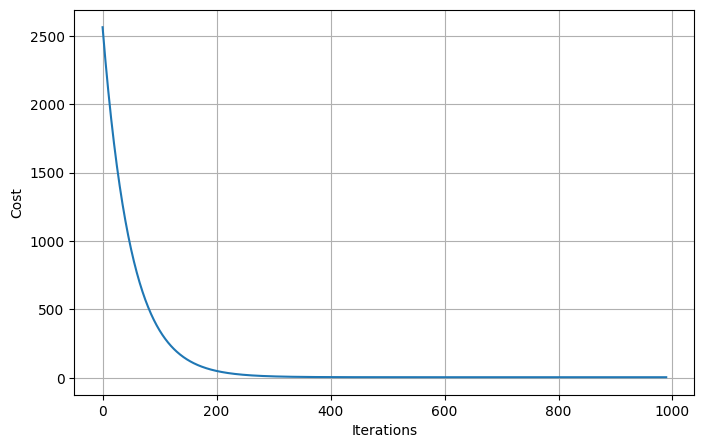

In [124]:
plt.figure(figsize=(8,5))
plt.plot(J_history[10:])
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.grid(True)
plt.show()

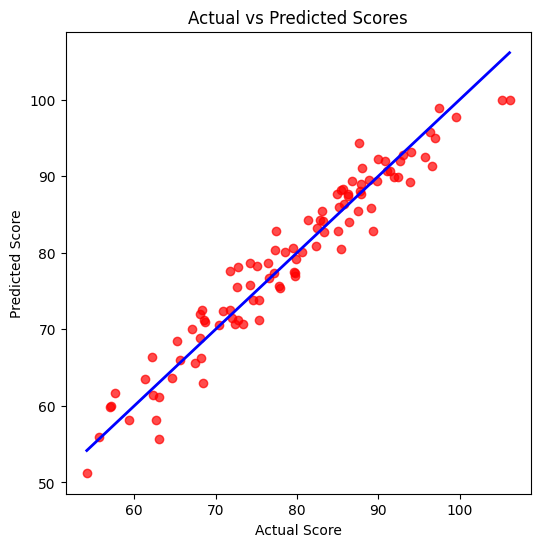

In [102]:
plt.figure(figsize=(6,6))
plt.scatter(y_train, y_pred, color='red', alpha=0.7)

# Perfect prediction line
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         'b', linewidth=2)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Scores")


plt.show()

In [99]:
new_student = np.array([6, 7,90, 77]) 

new_student_norm = (new_student - mu) / sigma

prediction = np.dot(new_student_norm, w) + b

print(f'Prediction for new student score is {prediction:.2f}')

Prediction for new student score is 90.98


Iteration    0: Cost  3191.61
Iteration  100: Cost  2613.10
Iteration  200: Cost  2139.59
Iteration  300: Cost  1752.02
Iteration  400: Cost  1434.81
Iteration  500: Cost  1175.16
Iteration  600: Cost   962.64
Iteration  700: Cost   788.69
Iteration  800: Cost   646.31
Iteration  900: Cost   529.77
Iteration    0: Cost  3134.39
Iteration  100: Cost   422.84
Iteration  200: Cost    60.13
Iteration  300: Cost    11.59
Iteration  400: Cost     5.09
Iteration  500: Cost     4.22
Iteration  600: Cost     4.10
Iteration  700: Cost     4.09
Iteration  800: Cost     4.09
Iteration  900: Cost     4.09
Iteration    0: Cost  2590.65
Iteration  100: Cost     4.09
Iteration  200: Cost     4.09
Iteration  300: Cost     4.09
Iteration  400: Cost     4.09
Iteration  500: Cost     4.09
Iteration  600: Cost     4.09
Iteration  700: Cost     4.09
Iteration  800: Cost     4.09
Iteration  900: Cost     4.09


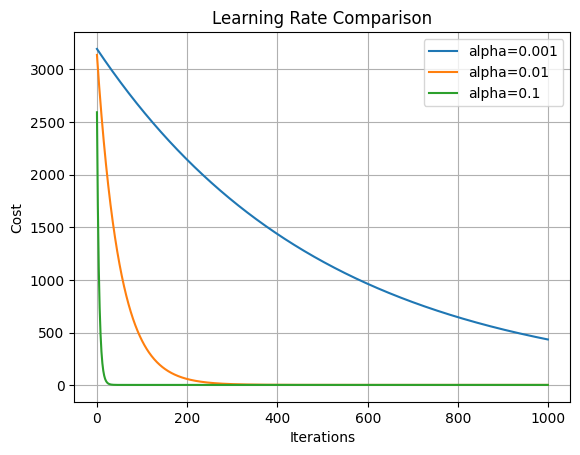

In [127]:
#Check different alpha values

alphas = [0.001, 0.01, 0.1]

for alpha in alphas:
    w, b, J_history, _ = gradient_descent(
        X_train_norm,
        y_train,
        np.zeros(X_train_norm.shape[1]),
        0,
        compute_cost,
        compute_gradient,
        alpha,
        1000
    )
    plt.plot(J_history, label=f"alpha={alpha}")

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Learning Rate Comparison")
plt.legend()
plt.grid(True)
plt.show()